A cena nomeada TP2_roadmap.ttt 

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import time
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

In [52]:
# Parametros do Mapa e Grid
MAP_MIN = -25.0
MAP_MAX = 25.0
GRID_RESOLUTION = 0.07 # Resolucao do grid em metros
GRID_SIZE = int((MAP_MAX - MAP_MIN)/GRID_RESOLUTION)
INFLATION = 0.2 # Margem de segurança ao redor dos obstaculos(em metros)

In [53]:
# Funcao de conversao de coordenadas. Converte coordenadas do mundo (metros) para coordenadas do grid
def world_to_grid(world_coords):
    grid_x = int((world_coords[0] - MAP_MIN)/GRID_RESOLUTION)
    grid_y = int((world_coords[1] - MAP_MIN)/GRID_RESOLUTION)
    return grid_x,grid_y

In [54]:
# Converte coordenadas do grid (indices) para coordenadas do mundo (metros)
def grid_to_world(grid_coords):
    world_x = grid_coords[0] * GRID_RESOLUTION + MAP_MIN
    world_y = grid_coords[1] * GRID_RESOLUTION + MAP_MIN
    return np.array([world_x, world_y])

Gerando o mapa a partir da cena do CoppeliaSim
Mapa gerado com sucesso


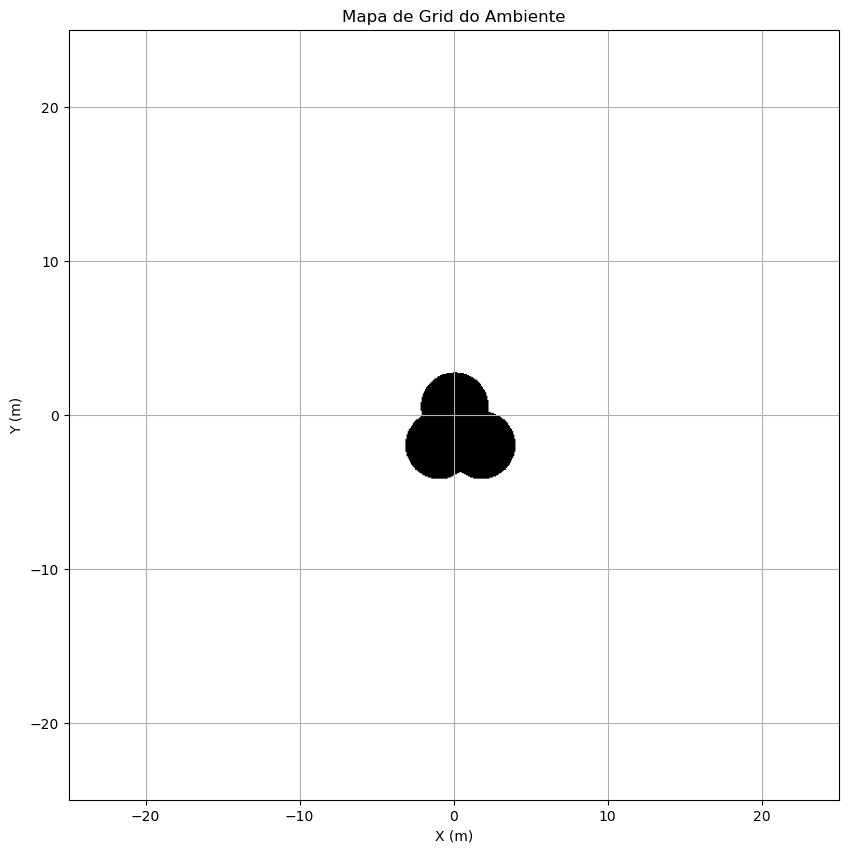

In [ ]:
# Criação do mapa
print("Gerando o mapa a partir da cena do CoppeliaSim")

grid_map = np.zeros((GRID_SIZE, GRID_SIZE))

try:
    client = RemoteAPIClient()
    sim = client.require("sim")

    # Garante que a simulação esteja para para pegar as posicoes iniciais
    if sim.getSimulationState() != sim.simulation_stopped:
        sim.stopSimulation()
        time.sleep(1)

    # Obtenção dos handles dos obstaculos
    obstacle_names = [f'Obstacle{i}' for i in range(1,4)]
    obstacle_handles = [sim.getObject('/' + name) for name in obstacle_names]
    obstacle_radius = 2+INFLATION # Raio fixo para todos os obstaculos

    # Otmizacao: Busca posicao uma vez so
    obstacle_positions = []
    for handle in obstacle_handles:
        obs_pos_3d = sim.getObjectPosition(handle, sim.handle_world)
        obstacle_positions.append(np.array([obs_pos_3d[0],obs_pos_3d[1]]))
    obstacle_positions = np.array(obstacle_positions)

    # Marcacao dos obstaculos no grid
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            cell_world_pos = grid_to_world((x,y))

            # Calcula todas as distancias de uma vez
            distances = np.linalg.norm(obstacle_positions - cell_world_pos, axis=1)
            if np.any(distances < obstacle_radius):
                grid_map[y,x] = 1 # Marca como obstaculo
    print('Mapa gerado com sucesso')

except Exception as e:
    print(f'Ocorreu um erro: {e}')

# Plot do Mapa
plt.figure(figsize=(10,10))
plt.imshow(grid_map,cmap='gray_r', origin='lower', extent=[MAP_MIN, MAP_MAX, MAP_MIN, MAP_MAX])
plt.title("Mapa de Grid do Ambiente")
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid(True)
plt.show()

Obtendo a posicao inicial do robo no CoppeliaSim
Posicao inicial lida do robo: [-2.15057028  1.53750663]
Start grid: (326, 379), Goal grid: (428, 428)
Encontrando o caminho com o algoritmo A*
Path: [<GridNode(326:379 0x7077c2dd1650)>, <GridNode(327:380 0x707780b0ca10)>, <GridNode(328:381 0x707780b37d90)>, <GridNode(329:382 0x707780b67150)>, <GridNode(330:383 0x707780b9a510)>, <GridNode(331:384 0x707780bc98d0)>, <GridNode(332:385 0x7077919f3350)>, <GridNode(333:386 0x707791924050)>, <GridNode(334:387 0x70779194b3d0)>, <GridNode(335:388 0x70779197a790)>, <GridNode(336:389 0x7077919a9b50)>, <GridNode(337:390 0x7077919dcf10)>, <GridNode(338:391 0x7077909142d0)>, <GridNode(339:392 0x70779093f650)>, <GridNode(340:393 0x707790976a10)>, <GridNode(341:394 0x7077909a5dd0)>, <GridNode(342:395 0x7077909d9190)>, <GridNode(343:396 0x70777ef00550)>, <GridNode(344:396 0x70777ef00590)>, <GridNode(345:396 0x70777ef005d0)>, <GridNode(346:396 0x70777ef00610)>, <GridNode(347:396 0x70777ef00650)>, <GridNode

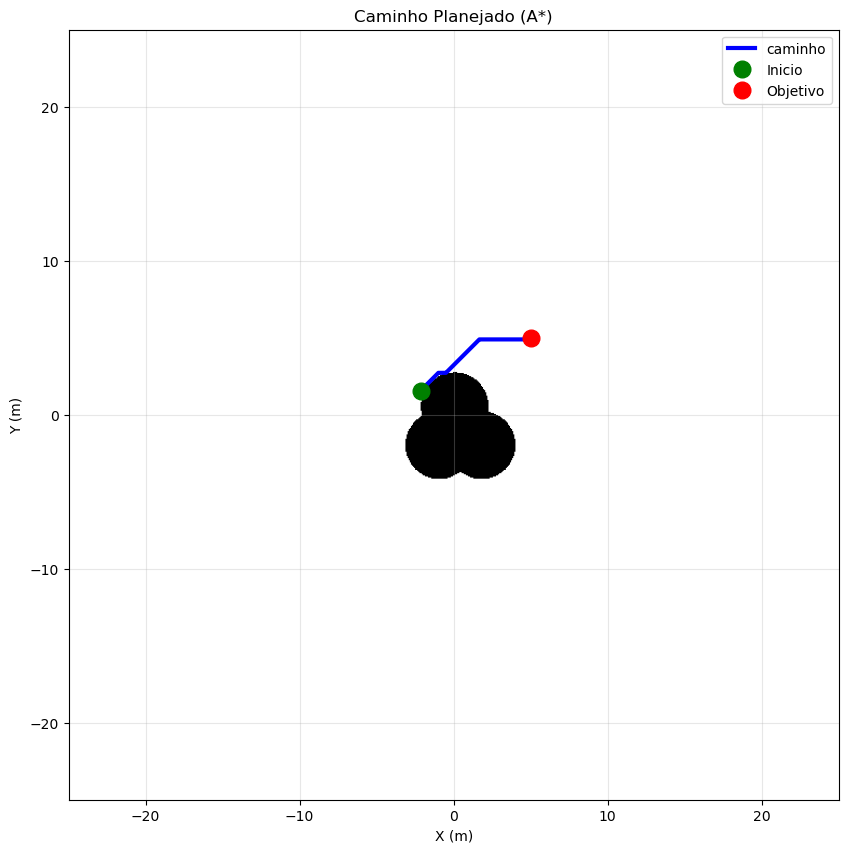

In [56]:
from pathfinding.core.diagonal_movement import DiagonalMovement
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder

# Ponto de Fim (alvo)
# Posicao do alvo no sistema de coordenadas do CoppeliaSim
goal_pos_world = np.array([5, 5])

try:
    # Leitura da Posicao Inicial do Robot no CoppeliaSim
    print("Obtendo a posicao inicial do robo no CoppeliaSim")
    client = RemoteAPIClient()
    sim = client.require("sim")

    # Garante que a simulação esteja para para pegar as posicoes iniciais
    if sim.getSimulationState() != sim.simulation_stopped:
        sim.stopSimulation()
        time.sleep(1)

    robotname = 'robotino'
    robotHandle = sim.getObject('/' + robotname)
    start_pos_3d = sim.getObjectPosition(robotHandle, sim.handle_world)
    start_pos_world = np.array([start_pos_3d[0],start_pos_3d[1]])

    print(f'Posicao inicial lida do robo: {start_pos_world}')

    # Conversao das coordenadas para o grid
    start_node_grid = world_to_grid(start_pos_world)
    goal_node_grid = world_to_grid(goal_pos_world)

    print(f'Start grid: {start_node_grid}, Goal grid: {goal_node_grid}')

    if grid_map[start_node_grid[1], start_node_grid[0]] == 1:
        print("Aviso: o robo esta em cima de um obstaculo")
    if grid_map[goal_node_grid[1], goal_node_grid[0]] == 1:
        print("Aviso: o alvo esta em cima de um obstaculo")

    # Execucao do algoritmo A*
    print("Encontrando o caminho com o algoritmo A*")

    # Inverte o grid_map: A* precisa de 1 para celulas livres e 0 para obstaculos
    walkable_grid = 1 - grid_map.astype(int)

    # Cria o grid para o pathfinding
    grid = Grid(matrix=walkable_grid)

    # Define os nos de inicio e fim
    start = grid.node(start_node_grid[0], start_node_grid[1])
    end = grid.node(goal_node_grid[0],goal_node_grid[1])
    
    # Cria o finder e executa a busca
    finder = AStarFinder(diagonal_movement=DiagonalMovement.always)
    path, runs = finder.find_path(start, end, grid)
    print(f'Path: {path}')

    if path:
        print(f"Caminho encontrado com {len(path)} pontos")

        # Visualizacao simples do caminho do mapa
        plt.figure(figsize=(10,10))
        plt.imshow(grid_map,cmap='gray_r', origin='lower', extent=[MAP_MIN, MAP_MAX, MAP_MIN, MAP_MAX])

        # Converter o caminho para coordenadas do mundo
        path_world_vis = np.array([grid_to_world((node.x, node.y)) for node in path])

        # Plota o caminho em azul
        plt.plot(path_world_vis[:,0], path_world_vis[:,1], 'b-', linewidth=3, label ="caminho")

        # Marca inicio (verde) e fim (vermelho)
        plt.plot(start_pos_world[0], start_pos_world[1], 'go', markersize=12, label='Inicio')
        plt.plot(goal_pos_world[0], goal_pos_world[1], 'ro', markersize=12, label='Objetivo')
        plt.title("Caminho Planejado (A*)")
        plt.xlabel('X (m)')
        plt.ylabel('Y (m)')
        plt.legend()
        plt.grid(True,alpha=0.3)
        plt.show()
    else:
        print("Erro: Nenhum caminho foi encontrado")

except Exception as e:
    print(f'Ocorreu um erro: {e}')

### Movimento do Robo

In [57]:
print("Iniciando o controle do robo para seguir o caminho")
# Matriz de rotação em relação a Z
def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])


try:
    client = RemoteAPIClient()
    sim = client.require("sim")

    # Handle para o ROBÔ
    robotname = 'robotino'
    robotHandle = sim.getObject('/' + robotname)
    
    # Handle para as juntas das RODAS
    wheel0 = sim.getObject('/'+robotname+'/wheel0_joint')
    wheel1 = sim.getObject('/'+robotname+'/wheel1_joint')
    wheel2 = sim.getObject('/'+robotname+'/wheel2_joint')

    # Dados Robotino
    L = 0.135   # Metros
    r = 0.040   # Metros  
    
    # Cinemática Direta
    Mdir = np.array([[-r/np.sqrt(3), 0, r/np.sqrt(3)], [r/3, (-2*r)/3, r/3], [r/(3*L), r/(3*L), r/(3*L)]])
    gain = np.array([[3.5, 0, 0], [0, 3.5, 0], [0, 0, 0.75]])

    # Conversao do caminho e Preparacao
    # converte o caminho do grid para coordenadas do mundo
    path_world = [grid_to_world((node.x, node.y)) for node in path]

    # Inicia a simulação
    sim.setStepping(True)
    sim.startSimulation()
    
    print("Starting robot control loop...")
    for i, waypoint in enumerate(path_world):
        print(f'Indo para o waypoint {i+1}/{len(path_world)} :{waypoint}')

        # o alvo (qgoal) é o waypoint atual (x,y)
        qgoal = np.zeros(3)
        qgoal[:2] = waypoint

        if i < len(path_world) - 1:
            next_waypoint = path_world[i+1]

            # Calcula o angulo para o proximo ponto
            angle_to_next = np.arctan2(next_waypoint[1] - waypoint[1], next_waypoint[0] - waypoint[0])
            qgoal[2] = angle_to_next
        else:
            # Para o ultimo ponto, mantem a orientacao do penultimo
            qgoal[2] = q[2] if 'q' in locals() else 0

        # Loop para alcancar o waypoint atual
        while True:
            pos = sim.getObjectPosition(robotHandle, sim.handle_world)
            ori = sim.getObjectOrientation(robotHandle, sim.handle_world)

            q = np.array([pos[0], pos[1], ori[2]])
            
            error = qgoal - q
            error[2] = np.arctan2(np.sin(error[2]), np.cos(error[2]))
            
            # Margem aceitável de distância
            if (np.linalg.norm(error[:2]) < 0.05):
                break

            # Controller
            qdot = gain @ error
            
            # Cinemática Inversa
            # w1, w2, w3
            Minv = np.linalg.inv(Rz(q[2]) @ Mdir)
            u = Minv @ qdot
            
            # Enviando velocidades
            sim.setJointTargetVelocity(wheel0, u[0])
            sim.setJointTargetVelocity(wheel1, u[1])
            sim.setJointTargetVelocity(wheel2, u[2]) 
                    
            sim.step()

    # Parando o robô
    print("Stopping robot...")
    sim.setJointTargetVelocity(wheel0, 0)
    sim.setJointTargetVelocity(wheel1, 0)
    sim.setJointTargetVelocity(wheel2, 0)
    
except Exception as e:
    print(f"An error occurred: {e}")
sim.stopSimulation()
print('Program ended')

Iniciando o controle do robo para seguir o caminho
Starting robot control loop...
Indo para o waypoint 1/103 :[-2.18  1.53]
Indo para o waypoint 2/103 :[-2.11  1.6 ]
Indo para o waypoint 3/103 :[-2.04  1.67]
Indo para o waypoint 4/103 :[-1.97  1.74]
Indo para o waypoint 5/103 :[-1.9   1.81]
Indo para o waypoint 6/103 :[-1.83  1.88]
Indo para o waypoint 7/103 :[-1.76  1.95]
Indo para o waypoint 8/103 :[-1.69  2.02]
Indo para o waypoint 9/103 :[-1.62  2.09]
Indo para o waypoint 10/103 :[-1.55  2.16]
Indo para o waypoint 11/103 :[-1.48  2.23]
Indo para o waypoint 12/103 :[-1.41  2.3 ]
Indo para o waypoint 13/103 :[-1.34  2.37]
Indo para o waypoint 14/103 :[-1.27  2.44]
Indo para o waypoint 15/103 :[-1.2   2.51]
Indo para o waypoint 16/103 :[-1.13  2.58]
Indo para o waypoint 17/103 :[-1.06  2.65]
Indo para o waypoint 18/103 :[-0.99  2.72]
Indo para o waypoint 19/103 :[-0.92  2.72]
Indo para o waypoint 20/103 :[-0.85  2.72]
Indo para o waypoint 21/103 :[-0.78  2.72]
Indo para o waypoint 22/